Clean dataset size: 1759

Class distribution:
 label
Health                        131
Education                     121
Infrastructure                120
Governance                    113
Environmental Policy          112
Water Resources               111
Trade and Industry            110
Technology and Innovation     103
Urban Development              99
Agriculture                    98
Rural Development              98
Social Protection              98
Public Administration          88
Economic Development           81
Energy                         76
Education                      14
Environmental Policy           14
Technology and Innovation      14
Water Resources                14
Economic Development           14
Health                         14
Trade and Industry             14
Governance                     14
Infrastructure                 14
Urban Development              14
Agriculture                    12
Social Protection              12
Energy                       

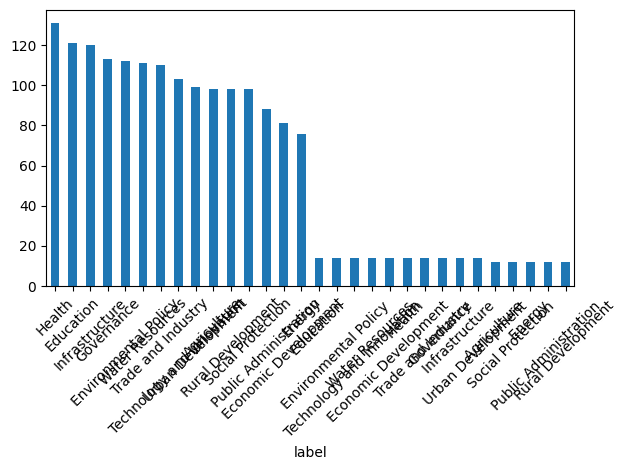

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load dataset
# !!! IMPORTANT: The file 'datsets.csv' was not found.
# Please replace 'your_dataset_name.csv' with the correct path to your CSV file.
# If you need to upload a file, use: from google.colab import files; uploaded = files.upload()
df = pd.read_csv("/content/datsets.csv")

# Standardize columns
df.columns = [c.strip().lower() for c in df.columns]

# Map columns
text_col = [c for c in df.columns if "content" in c or "text" in c][0]
lang_col = [c for c in df.columns if "lang" in c][0]
label_col = [c for c in df.columns if "label" in c or "domain" in c][0]

# Create clean dataset
clean_df = pd.DataFrame({
    "id": range(1, len(df)+1),
    "text": df[text_col],
    "language": df[lang_col],
    "label": df[label_col]
})

# Clean data
clean_df = clean_df.dropna()
clean_df = clean_df[clean_df["label"] != "Domain Label"]

# Remove rare classes
counts = clean_df["label"].value_counts()
valid_labels = counts[counts > 1].index
clean_df = clean_df[clean_df["label"].isin(valid_labels)]

print("Clean dataset size:", len(clean_df))
print("\nClass distribution:\n", clean_df["label"].value_counts())

# Create output folder
os.makedirs("output/data", exist_ok=True)
os.makedirs("output/figures", exist_ok=True)

# Split dataset
train, temp = train_test_split(clean_df, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

# Save splits
train.to_csv("output/data/train.csv", index=False)
val.to_csv("output/data/val.csv", index=False)
test.to_csv("output/data/test.csv", index=False)

# Save statistics
clean_df["label"].value_counts().to_csv("output/data/class_distribution.csv")
clean_df["language"].value_counts().to_csv("output/data/language_distribution.csv")

# Plot
plt.figure()
clean_df["label"].value_counts().plot(kind="bar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/figures/class_distribution.png")

# Generate LaTeX table
latex = "\\begin{table}[t]\n\\centering\n\\caption{Class distribution}\n\\begin{tabular}{lc}\n\\hline\nClass & Count \\\\n\\hline\n"

for label, count in clean_df["label"].value_counts().items():
    latex += f"{label} & {count} \\\\n"

latex += "\\hline\n\\end{tabular}\n\\end{table}"

with open("output/class_table.tex", "w") as f:
    f.write(latex)

print("\n✅ DONE! Files saved in 'output/' folder")